# Configuracion

In [ ]:
!git clone https://github.com/KristofPusztai/EQL.git
%cd EQL
!pip install tf_keras numpy sympy matplotlib
import os
os.environ["TF_USE_LEGACY_KERAS"] = "True"

Cloning into 'EQL'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 365 (delta 21), reused 39 (delta 12), pack-reused 304 (from 1)
Receiving objects: 100% (365/365), 786.72 KiB | 20.70 MiB/s, done.
Resolving deltas: 100% (168/168), done.
/content/EQL


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from EQL.model import EQL
from sympy import symbols, lambdify
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import os, itertools, random, sympy as sp
import matplotlib.pyplot as plt

/content/EQL/EQL/model.py:434: SyntaxWarning: invalid escape sequence '\s'
  output[activation] = Function('\sigma')(output[activation])


# Nguyen

## Funciones Utiles para Nguyen

In [ ]:
def generate_nguyen_data(func_id, n_samples=512, extrapolation=False):
    """
    Genera dataset sintético para funciones Nguyen-1 a 12.
    """
    rng = np.random.default_rng()

    # ---- Definiciones del paper Nguyen (Uy et al., 2010)
    x = None
    if func_id == 1:
        f = lambda x: x**3 + x**2 + x
        dim = 1
    elif func_id == 2:
        f = lambda x: x**4 + x**3 + x**2 + x
        dim = 1
    elif func_id == 3:
        f = lambda x: x**5 + x**4 + x**3 + x**2 + x
        dim = 1
    elif func_id == 4:
        f = lambda x: x**6 + x**5 + x**4 + x**3 + x**2 + x
        dim = 1
    elif func_id == 5:
        f = lambda x: np.sin(x**2)*np.cos(x) - 1
        dim = 1
    elif func_id == 6:
        f = lambda x: np.sin(x) + np.sin(x + x**2)
        dim = 1
    elif func_id == 7:
        f = lambda x: np.log(x**2 + 1) + np.log(x + 1)
        dim = 1
    elif func_id == 8:
        f = lambda x: np.sqrt(x)
        dim = 1
    elif func_id == 9:
        f = lambda x1, x2: np.sin(x1) + np.sin(x2**2)
        dim = 2
    elif func_id == 10:
        f = lambda x1, x2: 2*np.sin(x1)*np.cos(x2)
        dim = 2
    elif func_id == 11:
        f = lambda x1, x2: x1**x2
        dim = 2
    elif func_id == 12:
        f = lambda x1, x2: x1**4 - x1**3 + 0.5*x2**2 - x2
        dim = 2
    else:
        raise ValueError("func_id debe ser 1-12.")

    # ---- Rango de entrenamiento y extrapolación
    if extrapolation:
        if func_id == 7 or func_id == 8:
            X = rng.uniform(0, 6, size=(n_samples, dim))
        elif func_id == 11:
            # Caso especial x^y: base positiva extendida
            X = rng.uniform(0.1, 4.0, size=(n_samples, dim))
        else:
            X = rng.uniform(-2, 2, size=(n_samples, dim))

        # Filtro general de rango > 1 para extrapolación fuera de training
        if func_id != 11: # Nguyen 11 usa otro rango base
             mask = np.any(np.abs(X) > 1, axis=1)
             X = X[mask]
    else:
        if func_id == 7:
            X = rng.uniform(0, 2, size=(n_samples, dim))
        elif func_id == 8:
            X = rng.uniform(0, 4, size=(n_samples, dim))
        elif func_id == 11:
            # Caso especial x^y: base positiva estricta para training
            X = rng.uniform(0.1, 2.0, size=(n_samples, dim))
        else:
            X = rng.uniform(-1, 1, size=(n_samples, dim))

    # ---- Calcular y
    if dim == 1:
        y = f(X[:, 0])
    elif dim == 2:
        y = f(X[:, 0], X[:, 1])
    else:
        raise ValueError("Dimensionalidad no soportada.")

    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32), dim

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    """
    Calcula NRMSE y R² en train/test.
    """
    y_pred_train = model.predict(X_train, verbose=0)
    y_pred_test = model.predict(X_test, verbose=0)

    def nrmse(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        denom = np.max(y_true) - np.min(y_true)
        return rmse / denom if denom != 0 else rmse

    metrics = {
        "NRMSE_train": nrmse(y_train, y_pred_train),
        "NRMSE_test": nrmse(y_test, y_pred_test),
        "R2_train": r2_score(y_train, y_pred_train),
        "R2_test": r2_score(y_test, y_pred_test),
    }
    return metrics

In [ ]:
def plot_nguyen_fit(func_id, model, metrics=None, x_range=(-2, 2), n_points=400):
    """
    Grafica la función real del benchmark Nguyen y la predicha por el modelo EQL.
    Muestra además la ecuación recuperada y el R² en el título.
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import r2_score

    # ---- Determinar dimensionalidad
    if func_id in [1, 2, 3, 4, 5, 6, 7, 8]:
        dim = 1
    elif func_id in [9, 10, 11, 12]:
        dim = 2
    else:
        raise ValueError("func_id debe ser 1–12.")

    # ---- 1D: curva real vs predicha
    if dim == 1:
        # Definir rango (ajuste especial para log/sqrt)
        if func_id in [7, 8]:
            x = np.linspace(0.1, 4, n_points).astype(np.float32)
        else:
            x = np.linspace(x_range[0], x_range[1], n_points).astype(np.float32)

        # Generar vector de entrada para el modelo (Evita UnboundLocalError)
        X = x.reshape(-1, 1)

        # Calcular ground truth
        if func_id == 1:
            f_true = x**3 + x**2 + x
        elif func_id == 2:
            f_true = x**4 + x**3 + x**2 + x
        elif func_id == 3:
            f_true = x**5 + x**4 + x**3 + x**2 + x
        elif func_id == 4:
            f_true = x**6 + x**5 + x**4 + x**3 + x**2 + x
        elif func_id == 5:
            f_true = np.sin(x**2)*np.cos(x) - 1
        elif func_id == 6:
            f_true = np.sin(x) + np.sin(x + x**2)
        elif func_id == 7:
            f_true = np.log(x**2 + 1) + np.log(x + 1)
        elif func_id == 8:
            f_true = np.sqrt(x)

        # Predecir con el modelo
        f_pred = model.predict(X, verbose=0).flatten()

        # Calcular métrica si no viene dada
        r2_val = metrics["R2_test"] if metrics else r2_score(f_true, f_pred)

        # Graficar
        plt.figure(figsize=(8,4))
        plt.plot(x, f_true, label="Función real", linewidth=2, color='C0')
        plt.plot(x, f_pred, '--', label="Predicha (EQL)", linewidth=2, color='C1')
        plt.xlabel("x", fontsize=12)
        plt.ylabel("y", fontsize=12)
        plt.title(f"Nguyen-{func_id} | R²_test = {r2_val:.3f}",
                  fontsize=14, weight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---- 2D: mapa de contornos
    elif dim == 2:
        n_points_2d = 200

        # Ajuste de rango para Nguyen-11 (evitar negativos en la base)
        if func_id == 11:
            x1 = np.linspace(0.1, 2.0, n_points_2d) # Base positiva
            x2 = np.linspace(0.1, 2.0, n_points_2d)
        else:
            x1 = np.linspace(x_range[0], x_range[1], n_points_2d)
            x2 = np.linspace(x_range[0], x_range[1], n_points_2d)

        X1, X2 = np.meshgrid(x1, x2)

        if func_id == 9:
            f_true = np.sin(X1) + np.sin(X2**2)
        elif func_id == 10:
            f_true = 2*np.sin(X1)*np.cos(X2)
        elif func_id == 11:
            f_true = X1**X2
        elif func_id == 12:
            f_true = X1**4 - X1**3 + 0.5*X2**2 - X2

        X_flat = np.stack([X1.flatten(), X2.flatten()], axis=1).astype(np.float32)
        f_pred = model.predict(X_flat, verbose=0).reshape(X1.shape)

        # R² en test si existe
        r2_val = metrics["R2_test"] if metrics else None

        # Graficar
        fig, axs = plt.subplots(1, 2, figsize=(10,4))
        cs0 = axs[0].contourf(X1, X2, f_true, levels=50, cmap='viridis')
        cs1 = axs[1].contourf(X1, X2, f_pred, levels=50, cmap='viridis')
        fig.colorbar(cs0, ax=axs[0]); fig.colorbar(cs1, ax=axs[1])
        axs[0].set_title("Función real", weight='bold')
        axs[1].set_title(f"Predicha (EQL)" + (f"\nR²_test = {r2_val:.3f}" if r2_val else ""), weight='bold')
        for ax in axs:
            ax.set_xlabel("x₁"); ax.set_ylabel("x₂")
        plt.tight_layout()
        plt.show()

## Prueba Nguyen-1 $y=x^{3}+x^{2}+x$




Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5009/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0097
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5015/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0097
Epoch 5017/7000

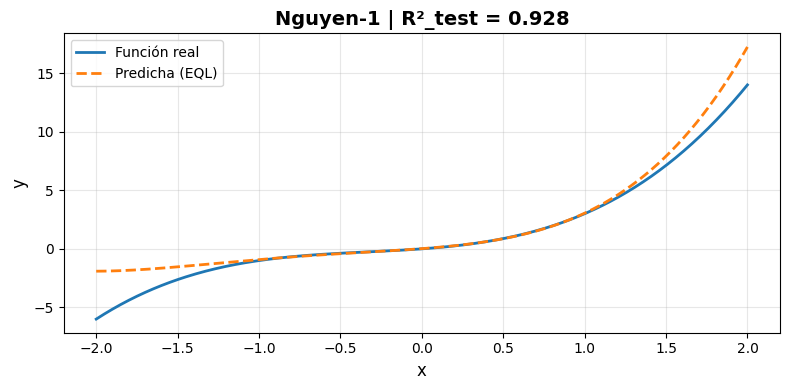

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 1
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

1.0000\*x_1^3 + 1.0000\*x_1^2 + 1.0000\*x_1

## Prueba Nguyen-2

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5015/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0095
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0095
Epoch 5017/7000

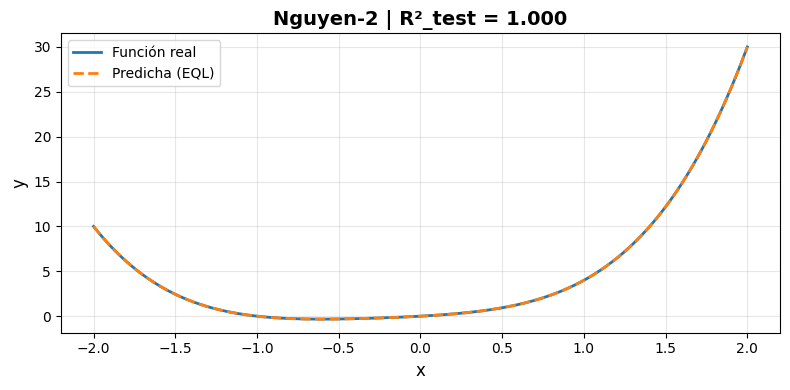

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 2
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

1.0000\*x_1^4 + 1.0000\*x_1^3 + 1.0000\*x_1^2 + 1.0000\*x_1 + 6.9628564589334e-7

## Prueba Nguyen-3

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0111
Epoch 5007/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0111
Epoch 5008/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0111
Epoch 5009/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0112
Epoch 5010/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0111
Epoch 5011/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0111
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0112
Epoch 5013/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0111
Epoch 5014/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0112
Epoch 5015/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0112
Epoch 5016/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0114
Epoch 5017/7000

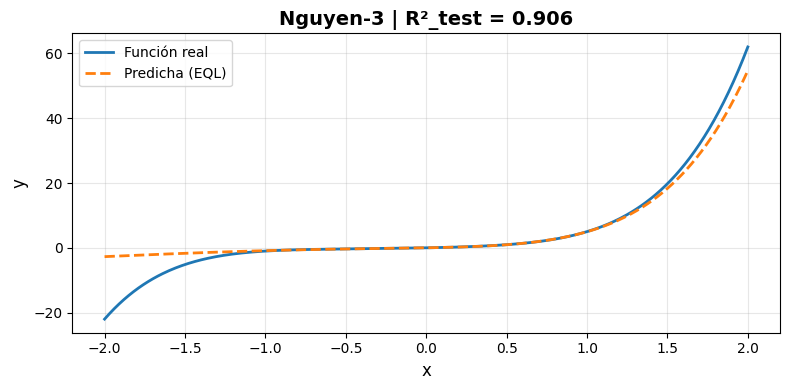

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 3
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

Ecuación recuperada:

0.0016*x_^8 + 0.0197*x_1^7 + 0.2078*x_1^6 + 0.9602*x_1^5 + 0.7200*x_1^4 + 1.0273*x_1^3 + 1.0961*x_1^2 + 0.9968*x_1 - 0.0044

## Prueba Nguyen-4

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0116
Epoch 5007/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0115
Epoch 5008/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0114
Epoch 5009/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0114
Epoch 5010/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0114
Epoch 5011/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0114
Epoch 5012/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0115
Epoch 5013/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0114
Epoch 5014/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0114
Epoch 5015/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0114
Epoch 5016/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0114
Epoch 5017/7000

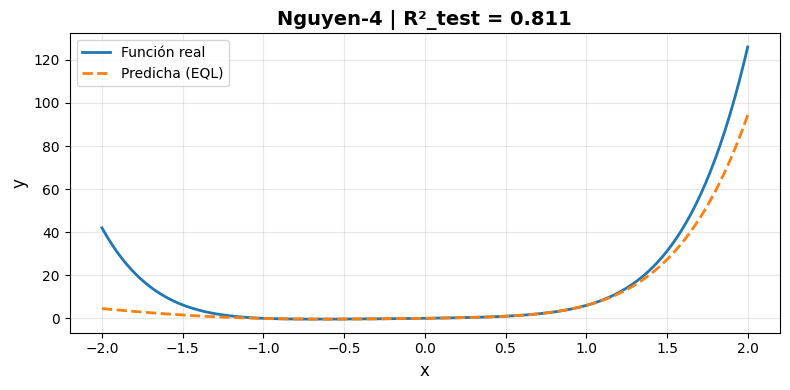

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 4
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-5

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5007/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0058
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5015/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0058
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0058
Epoch 5017/7000

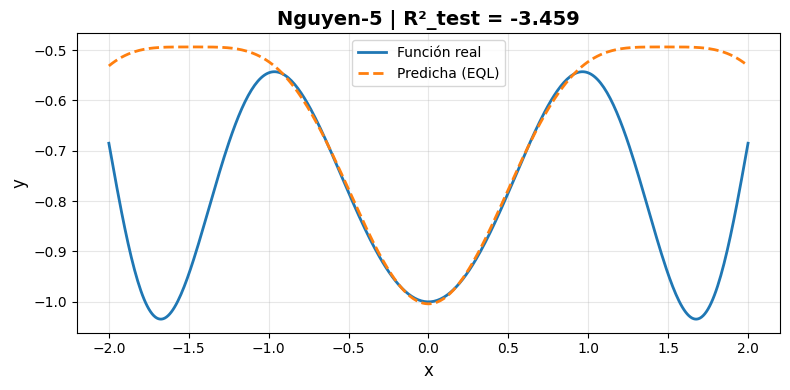

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 5
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-6

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0070
Epoch 5015/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0070
Epoch 5016/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0070
Epoch 5017/7000

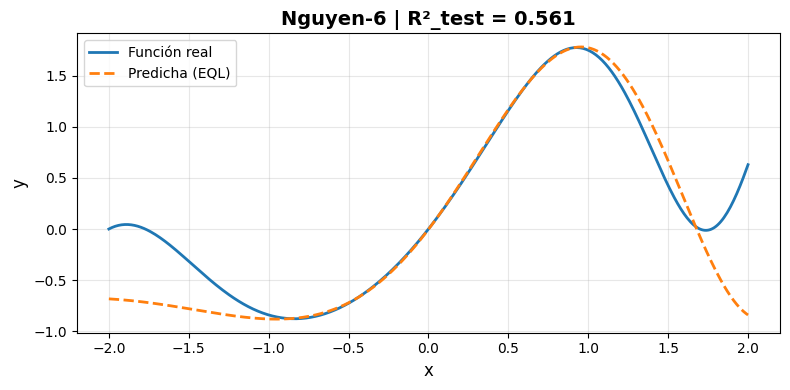

In [ ]:

# ---- Configuración del modelo
FUNC_ID   = 6
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-7 (EQL div)

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0059
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0059
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0060
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0060
Epoch 5010/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0060
Epoch 5011/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0060
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0059
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0059
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0060
Epoch 5015/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0060
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0060
Epoch 5017/7000

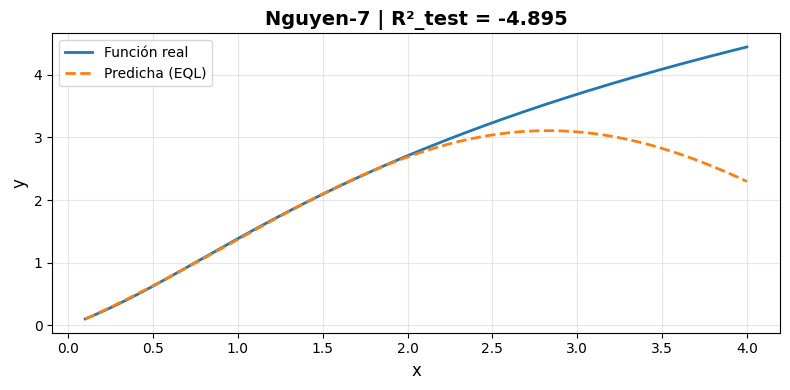

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 7
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-8 (EQL div)

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0062
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0061
Epoch 5008/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0061
Epoch 5009/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0061
Epoch 5010/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0062
Epoch 5011/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0062
Epoch 5012/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0062
Epoch 5013/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0062
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0062
Epoch 5015/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0061
Epoch 5016/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0061
Epoch 5017/7000

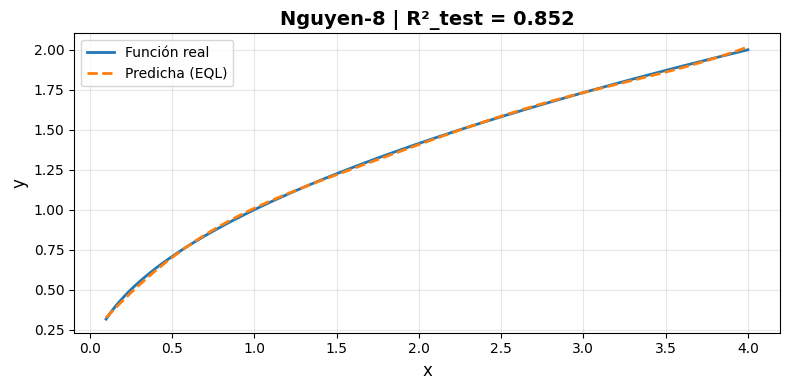

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 8
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

# ---- Mostrar resultados
print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-9

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5006/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0069
Epoch 5007/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0069
Epoch 5008/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0070
Epoch 5009/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0069
Epoch 5010/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0069
Epoch 5011/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0069
Epoch 5012/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0069
Epoch 5013/7000
16/16 [==============================] - 0s 7ms/step - loss: 0.0069
Epoch 5014/7000
16/16 [==============================] - 0s 8ms/step - loss: 0.0069
Epoch 5015/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0069
Epoch 5016/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0069
Epoch 5017/7000

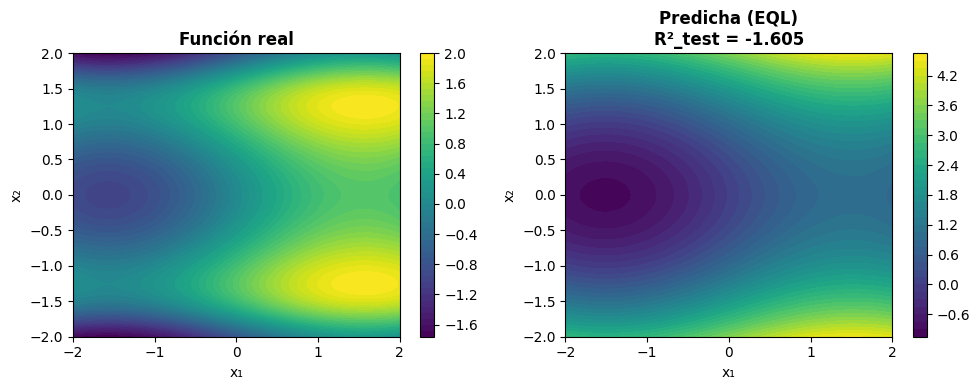

In [ ]:
# ---- Configuración del modelo
FUNC_ID   = 9
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
formula = model.formula(raw_latex=False, reduce=True)

print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")
print(f"\nEcuación recuperada:\n{formula}")

plot_nguyen_fit(FUNC_ID, model, metrics)
tf.keras.backend.clear_session()

## Prueba Nguyen-10

Se han truncado las últimas 5000 líneas del flujo de salida.
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5011/7000
16/16 [==============================] - 0s 6ms/step - loss: 0.0080
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5015/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5017/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0080
Epoch 5018/7000
16/16 [========

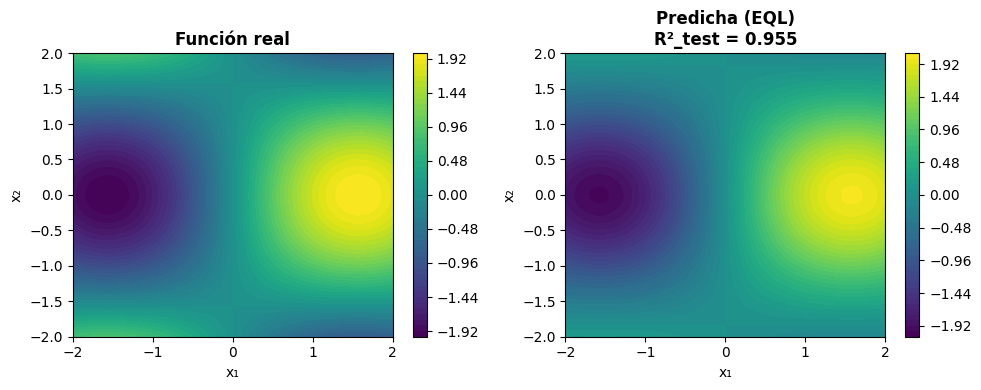

In [ ]:
1tf.keras.backend.clear_session()
# ---- Configuración del modelo
FUNC_ID   = 10
NUM_LAYERS = 3
LAMBDA    = 1e-3
SEED      = 1

# ---- Generar datos
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(
    w_init='random_normal', b_init='random_normal')

model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,   # fase de sparsity prolongada
    t2=500,   # fine-tune con L0
    batch_size=32,
    verbose=1,
    atol=1e-3)  # redondea pesos pequeños a 0


# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)
# ⚙️ obtener fórmula sin simplificar (rápido y seguro)
formula_raw = model.formula(raw_latex=False, reduce=False)

# Simplificar manualmente con sympy
import sympy as sp
x1, x2 = sp.symbols('x_1 x_2')
formula_simplificada = sp.simplify(sp.sympify(formula_raw))

print(f"\n=== Nguyen-{FUNC_ID} ===")
for k, v in metrics.items():
    print(f"{k:15s}: {v:.6f}")

print("\nEcuación simbólica (sin reducir):")
print(formula_raw)

print("\nEcuación simbólica simplificada:")
print(formula_simplificada)

plot_nguyen_fit(FUNC_ID, model, metrics)
tf.keras.backend.clear_session()


## Prueba Nguyen-11 (EQL div)

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5003/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5004/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0120
Epoch 5005/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5006/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0120
Epoch 5007/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5008/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5009/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0120
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0120
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0120
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0121
Epoch 5014/7000

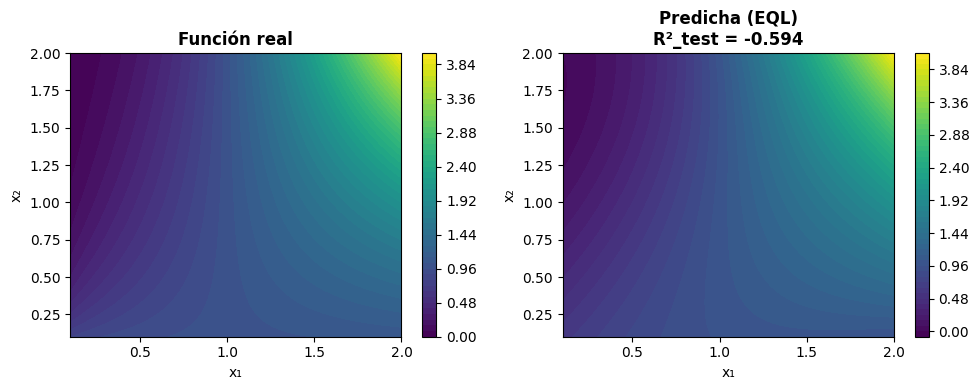


Procesando fórmula...

=== Nguyen-11 ===
NRMSE_train    : 0.008476
NRMSE_test     : 0.152925
R2_train       : 0.998127
R2_test        : -0.594089

Ecuación simbólica (sin reducir):
0.00719573270846783*x_1**2*(0.214554265141487*x_1 + 1.00934231281281*x_2)**2*(0.682185610592612*x_1*(0.214554265141487*x_1 + 1.00934231281281*x_2) + 0.107637077569962*cos(-1.19830858707428*x_1 + 1.09200727939606*x_2 + 1.25370275974274))**2 + 1.66462087631226*sin(0.0732734567116149*x_1*(0.214554265141487*x_1 + 1.00934231281281*x_2)*(0.682185610592612*x_1*(0.214554265141487*x_1 + 1.00934231281281*x_2) + 0.107637077569962*cos(-1.19830858707428*x_1 + 1.09200727939606*x_2 + 1.25370275974274)) + 0.522571086883545*sin(0.217045957720519*x_1*(0.214554265141487*x_1 + 1.00934231281281*x_2) + 0.590460240840912*cos(-1.19830858707428*x_1 + 1.09200727939606*x_2 + 1.25370275974274)) + 0.00554633839055896) + 0.42994961887598

Ecuación simbólica simplificada:
0.00719573270846783*x_1**2*(0.214554265141487*x_1 + 1.009342312812

In [ ]:
import tensorflow as tf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Función auxiliar para limpiar ruido (Vital para SymPy)
def podar_modelo(eql_model, umbral=0.1):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

tf.keras.backend.clear_session()

# ---- Configuración del modelo
FUNC_ID    = 11
NUM_LAYERS = 3
LAMBDA     = 1e-3
SEED       = 1

# ---- Generar datos (Usando la versión robusta definida antes)
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Nota: v=[1,2,1] es muy ajustado para x^y, pero la poda ayudará
model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("Iniciando entrenamiento...")
model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,    # fase de sparsity
    t2=500,     # fine-tune
    batch_size=32,
    verbose=1,
    atol=1e-3)

# ---- PODA OBLIGATORIA (Evita que SymPy se cuelgue)
print("\nLimpiando pesos residuales...")
eliminados = podar_modelo(model, umbral=0.1)
print(f"Limpieza completada: {eliminados} conexiones eliminadas.")

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)


# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Obtener y simplificar fórmula
print("\nProcesando fórmula...")
try:
    # 1. Obtener cruda
    formula_raw = model.formula(raw_latex=False, reduce=True)

    # 2. Simplificar con SymPy (ahora seguro tras la poda)
    # Definimos símbolos genéricos x0, x1... o los que use tu librería
    # Nota: EQL suele usar x0, x1. Ajusta según la salida raw.
    locals_dict = {f'x{i}': sp.Symbol(f'x{i}') for i in range(10)}
    expr = sp.sympify(formula_raw, locals=locals_dict)
    formula_simplificada = sp.simplify(expr)

    print(f"\n=== Nguyen-{FUNC_ID} ===")
    for k, v in metrics.items():
        print(f"{k:15s}: {v:.6f}")

    print("\nEcuación simbólica (sin reducir):")
    print(formula_raw)

    print("\nEcuación simbólica simplificada:")
    print(formula_simplificada)

except Exception as e:
    print(f"Error en simplificación simbólica: {e}")
    print("El modelo sigue siendo válido para gráficas.")



# ---- Limpiar sesión
tf.keras.backend.clear_session()

## Prueba Nguyen-12 (EQL div)

Se han truncado las últimas 5000 líneas del flujo de salida.
Epoch 5010/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5011/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5012/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0118
Epoch 5013/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5014/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0118
Epoch 5015/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5016/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5017/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5018/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5019/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5020/7000
16/16 [==============================] - 0s 5ms/step - loss: 0.0119
Epoch 5021/7000

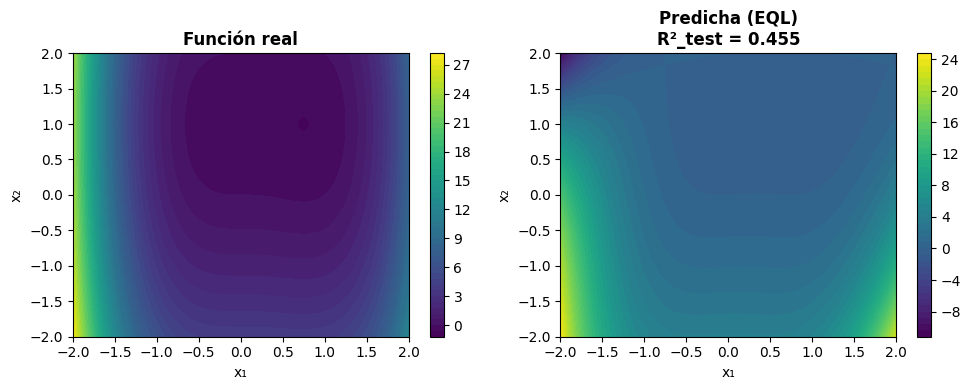

In [ ]:
import tensorflow as tf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Función auxiliar para limpiar ruido (Vital para SymPy)
def podar_modelo(eql_model, umbral=0.1):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

tf.keras.backend.clear_session()

# ---- Configuración del modelo
FUNC_ID    = 12
NUM_LAYERS = 3
LAMBDA     = 1e-3
SEED       = 1

# ---- Generar datos (Usando la versión robusta definida antes)
X_train, y_train, dim = generate_nguyen_data(FUNC_ID)
X_test,  y_test,  _   = generate_nguyen_data(FUNC_ID, extrapolation=True)

# ---- Entrenar el modelo
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Nota: v=[1,2,1] es muy ajustado para x^y, pero la poda ayudará
model = EQL(num_layers=NUM_LAYERS, dim=dim, v=[1, 2, 1])
model.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("Iniciando entrenamiento...")
model.fit(
    X_train, y_train,
    lmbda=LAMBDA,
    t0=2500,    # warm-up
    t1=7000,    # fase de sparsity
    t2=500,     # fine-tune
    batch_size=32,
    verbose=1,
    atol=1e-3)

# ---- PODA OBLIGATORIA (Evita que SymPy se cuelgue)
print("\nLimpiando pesos residuales...")
eliminados = podar_modelo(model, umbral=0.1)
print(f"Limpieza completada: {eliminados} conexiones eliminadas.")

# ---- Evaluar desempeño
metrics = evaluate_model(model, X_train, y_train, X_test, y_test)

# ---- Obtener y simplificar fórmula
print("\nProcesando fórmula...")
try:
    # 1. Obtener cruda
    formula_raw = model.formula(raw_latex=False, reduce=True)

    # 2. Simplificar con SymPy (ahora seguro tras la poda)
    # Definimos símbolos genéricos x0, x1... o los que use tu librería
    # Nota: EQL suele usar x0, x1. Ajusta según la salida raw.
    locals_dict = {f'x{i}': sp.Symbol(f'x{i}') for i in range(10)}
    expr = sp.sympify(formula_raw, locals=locals_dict)
    formula_simplificada = sp.simplify(expr)

    print(f"\n=== Nguyen-{FUNC_ID} ===")
    for k, v in metrics.items():
        print(f"{k:15s}: {v:.6f}")

    print("\nEcuación simbólica (sin reducir):")
    print(formula_raw)

    print("\nEcuación simbólica simplificada:")
    print(formula_simplificada)

except Exception as e:
    print(f"Error en simplificación simbólica: {e}")
    print("El modelo sigue siendo válido para gráficas.")

# ---- Graficar resultado
plot_nguyen_fit(FUNC_ID, model, metrics)

# ---- Limpiar sesión
tf.keras.backend.clear_session()

# Baterias

Pagina 16 del [8] se tiene que el número de Nusselt es función del número de Reynolds y el número de Prandtl, estando ambas expresiones ponderadas por una constante.

$Nu = C * Re^{n}*Pr^{m}$


## Cargar archivos y lector

## Obtencion ecuacion Nu

### Modelo linealizado

Se han truncado las últimas 5000 líneas del flujo de salida.
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5010/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5011/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5012/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5013/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5014/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5015/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5016/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0189
Epoch 5017/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5018/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5019/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0192
Epoch 5020/7000
93/93 [========

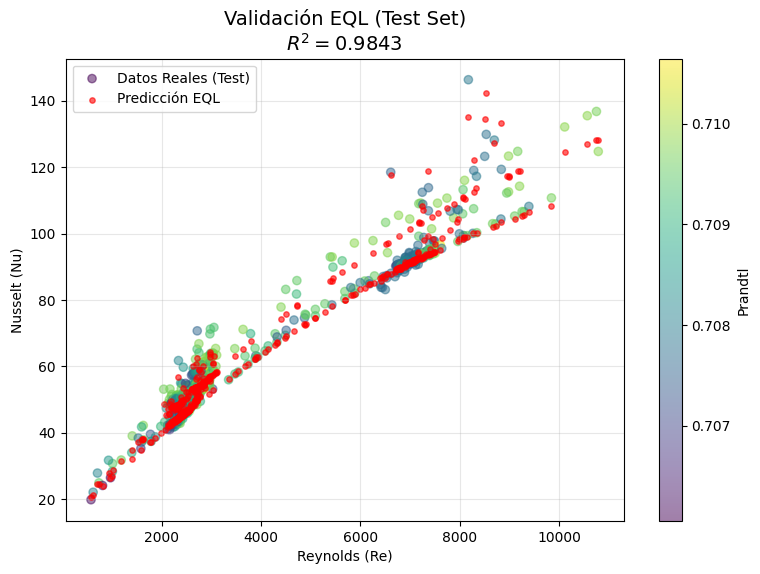

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from EQL.model import EQL

# --- FUNCIÓN DE SEGURIDAD (PODA) ---
def podar_modelo(eql_model, umbral):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
file_path = "/content/df_n_25.txt"

print("--- CARGANDO DATOS ---")
try:
    data = pd.read_csv(file_path)
    print(f"Archivo cargado: {file_path}")
except FileNotFoundError:
    print("Buscando ruta local...")
    try:
        data = pd.read_csv("df_n_25.txt")
        print("Archivo local cargado.")
    except:
        raise

# Limpieza física
data = data.dropna()
mask_valid = (data['Rem'] > 0) & (data['prandtl'] > 0) & (data['nusselt'] > 0)
data = data[mask_valid].copy()

# Definición variables
inputs = ['Rem', 'prandtl', 'K']
output = 'nusselt'

X_raw = data[inputs].values
y_raw = data[output].values.reshape(-1, 1)

print(f"Datos válidos: {len(data)}")

# --- 2. NORMALIZACIÓN ---
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0) + 1e-6
y_mean = y_raw.mean()
y_std  = y_raw.std() + 1e-6

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

ys, ym = y_std, y_mean

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# --- 3. CONFIGURACIÓN Y ENTRENAMIENTO ---
tf.keras.backend.clear_session()

# Configuración solicitada: v=[1, 2, 1]
num_inputs = X_train.shape[1]
eql_nu = EQL(num_layers=3, dim=num_inputs, v=[1, 2, 1])
eql_nu.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("\n--- INICIANDO ENTRENAMIENTO ---")
history = eql_nu.fit(
    X_train, y_train,
    lmbda=1e-3,
    t0=2500,
    t1=7000,
    t2=500,
    verbose=1, # Verbose activado
    atol=1e-3
)
print("Entrenamiento finalizado.")

# --- 4. EXTRACCIÓN DE FÓRMULA ---
print("\n--- PROCESANDO FÓRMULA ---")
podar_modelo(eql_nu, umbral=0.01)

# Chequeo anti-cuelgue
pesos_activos = sum(np.sum(np.abs(l.w.numpy()) > 0) for l in eql_nu.model.layers if hasattr(l, 'w'))
print(f"Pesos activos: {pesos_activos}")

if pesos_activos > 20:
    print(">> Poda agresiva (0.05) aplicada...")
    podar_modelo(eql_nu, umbral=0.05)

try:
    if pesos_activos <= 25:
        raw_formula = str(eql_nu.formula())
        translated = (raw_formula.replace("x0", "Re")
                                 .replace("x1", "Pr")
                                 .replace("x2", "K")
                                 .replace("x3", "1"))
        print("\n=== ECUACIÓN DESCUBIERTA ===")
        print(translated)
    else:
        print("Fórmula muy larga, se omite impresión.")
except Exception as e:
    print(f"No se pudo imprimir fórmula: {e}")

# --- 5. CÁLCULO DE MÉTRICAS (TRAIN y TEST) ---
print("\n--- RESULTADOS Y MÉTRICAS ---")

def get_metrics(X_n, y_n, model, label):
    # Desnormalizar Real
    y_real = y_n.flatten() * ys + ym
    # Predecir y Desnormalizar
    y_pred = model.predict(X_n, verbose=0).flatten() * ys + ym

    # Cálculos
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    rango = y_real.max() - y_real.min()
    nrmse = rmse / rango

    print(f"SET {label}:")
    print(f"  R^2 Score: {r2:.5f}")
    print(f"  NRMSE:     {nrmse:.5f} ({nrmse*100:.2f}%)")
    return r2, y_real, y_pred

# Métricas Train
r2_train, _, _ = get_metrics(X_train, y_train, eql_nu, "ENTRENAMIENTO")
print("-" * 30)
# Métricas Test
r2_test, y_test_real, y_pred_test = get_metrics(X_test, y_test, eql_nu, "TEST")
print("-" * 30)

# --- 6. GRÁFICO (SOLO TEST) ---
# Preparar eje X (Reynolds) desnormalizado
X_test_real = X_test * X_std + X_mean
Re_test_real = X_test_real[:, 0]
Pr_test_real = X_test_real[:, 1] # Para color

plt.figure(figsize=(9, 6))

# Datos Reales
sc = plt.scatter(Re_test_real, y_test_real,
                 c=Pr_test_real, cmap='viridis',
                 alpha=0.5, label='Datos Reales (Test)')

# Predicción
plt.scatter(Re_test_real, y_pred_test,
            color='red', s=15, alpha=0.6, label='Predicción EQL')

plt.colorbar(sc, label='Prandtl')
plt.xlabel('Reynolds (Re)')
plt.ylabel('Nusselt (Nu)')
plt.title(f'Validación EQL (Test Set)\n$R^2 = {r2_test:.4f}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
raw_formula = str(eql_nu.formula())
translated = (raw_formula.replace("x_1", "Re")
                                 .replace("x_2", "Pr")
                                 .replace("x_3", "K")
                                 .replace("x3", "1"))
print("\n=== ECUACIÓN DESCUBIERTA ===")
print(translated)


=== ECUACIÓN DESCUBIERTA ===
0.962557889647294*Re - 0.254178704712602*(0.117071352899075*Pr + 0.880813419818878*K)*(0.325134307146072*Re - 0.209457263350487*K + 0.560357213020325) + 0.451837103732025*(0.416785657405853*(0.117071352899075*Pr + 0.880813419818878*K)*(0.325134307146072*Re - 0.209457263350487*K + 0.560357213020325) + 0.132197387516499)*(0.41679647564888*(0.117071352899075*Pr + 0.880813419818878*K)*(0.325134307146072*Re - 0.209457263350487*K + 0.560357213020325) + 0.132122337818146) - 0.421959643644641*(-0.525027901219801*Re + 0.130608558654785*\sigma(0) + 0.261226415634155)*(-0.52500745179384*Re + 0.130628243088722*\sigma(0) + 0.261323988437653) + 0.0292408670667028


Se han truncado las últimas 5000 líneas del flujo de salida.
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5010/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5011/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5012/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5013/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5014/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5015/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5016/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0189
Epoch 5017/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5018/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5019/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0192
Epoch 5020/7000
93/93 [========

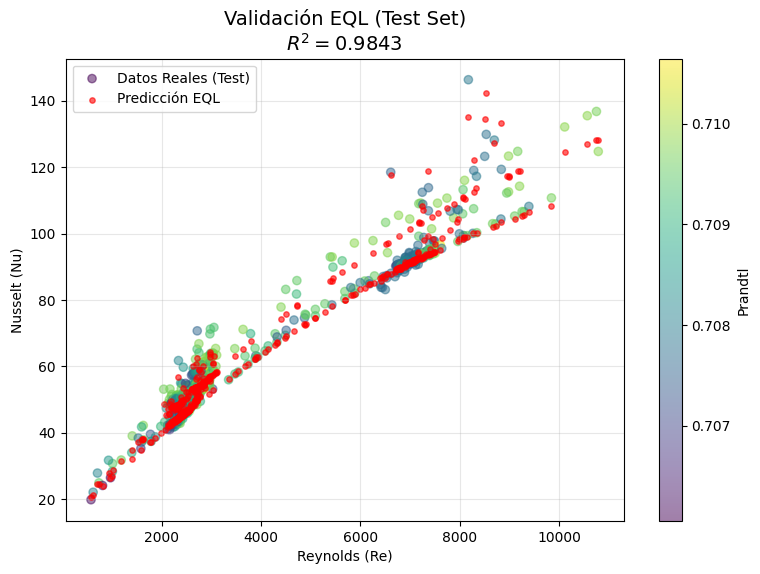

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from EQL.model import EQL

# --- FUNCIÓN DE SEGURIDAD (PODA) ---
def podar_modelo(eql_model, umbral):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
file_path = "/content/df_n_53.txt"

print("--- CARGANDO DATOS ---")
try:
    data = pd.read_csv(file_path)
    print(f"Archivo cargado: {file_path}")
except FileNotFoundError:
    print("Buscando ruta local...")
    try:
        data = pd.read_csv("df_n_25.txt")
        print("Archivo local cargado.")
    except:
        raise

# Limpieza física
data = data.dropna()
mask_valid = (data['Rem'] > 0) & (data['prandtl'] > 0) & (data['nusselt'] > 0)
data = data[mask_valid].copy()

# Definición variables
inputs = ['Rem', 'prandtl', 'K']
output = 'nusselt'

X_raw = data[inputs].values
y_raw = data[output].values.reshape(-1, 1)

print(f"Datos válidos: {len(data)}")

# --- 2. NORMALIZACIÓN ---
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0) + 1e-6
y_mean = y_raw.mean()
y_std  = y_raw.std() + 1e-6

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

ys, ym = y_std, y_mean

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# --- 3. CONFIGURACIÓN Y ENTRENAMIENTO ---
tf.keras.backend.clear_session()

# Configuración solicitada: v=[1, 2, 1]
num_inputs = X_train.shape[1]
eql_nu = EQL(num_layers=3, dim=num_inputs, v=[1, 2, 1])
eql_nu.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("\n--- INICIANDO ENTRENAMIENTO ---")
history = eql_nu.fit(
    X_train, y_train,
    lmbda=1e-3,
    t0=2500,
    t1=7000,
    t2=500,
    verbose=1, # Verbose activado
    atol=1e-3
)
print("Entrenamiento finalizado.")

# --- 4. EXTRACCIÓN DE FÓRMULA ---
print("\n--- PROCESANDO FÓRMULA ---")
podar_modelo(eql_nu, umbral=0.01)

# Chequeo anti-cuelgue
pesos_activos = sum(np.sum(np.abs(l.w.numpy()) > 0) for l in eql_nu.model.layers if hasattr(l, 'w'))
print(f"Pesos activos: {pesos_activos}")

if pesos_activos > 20:
    print(">> Poda agresiva (0.05) aplicada...")
    podar_modelo(eql_nu, umbral=0.05)

try:
    if pesos_activos <= 25:
        raw_formula = str(eql_nu.formula())
        translated = (raw_formula.replace("x0", "Re")
                                 .replace("x1", "Pr")
                                 .replace("x2", "K")
                                 .replace("x3", "1"))
        print("\n=== ECUACIÓN DESCUBIERTA ===")
        print(translated)
    else:
        print("Fórmula muy larga, se omite impresión.")
except Exception as e:
    print(f"No se pudo imprimir fórmula: {e}")

# --- 5. CÁLCULO DE MÉTRICAS (TRAIN y TEST) ---
print("\n--- RESULTADOS Y MÉTRICAS ---")

def get_metrics(X_n, y_n, model, label):
    # Desnormalizar Real
    y_real = y_n.flatten() * ys + ym
    # Predecir y Desnormalizar
    y_pred = model.predict(X_n, verbose=0).flatten() * ys + ym

    # Cálculos
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    rango = y_real.max() - y_real.min()
    nrmse = rmse / rango

    print(f"SET {label}:")
    print(f"  R^2 Score: {r2:.5f}")
    print(f"  NRMSE:     {nrmse:.5f} ({nrmse*100:.2f}%)")
    return r2, y_real, y_pred

# Métricas Train
r2_train, _, _ = get_metrics(X_train, y_train, eql_nu, "ENTRENAMIENTO")
print("-" * 30)
# Métricas Test
r2_test, y_test_real, y_pred_test = get_metrics(X_test, y_test, eql_nu, "TEST")
print("-" * 30)

# --- 6. GRÁFICO (SOLO TEST) ---
# Preparar eje X (Reynolds) desnormalizado
X_test_real = X_test * X_std + X_mean
Re_test_real = X_test_real[:, 0]
Pr_test_real = X_test_real[:, 1] # Para color

plt.figure(figsize=(9, 6))

# Datos Reales
sc = plt.scatter(Re_test_real, y_test_real,
                 c=Pr_test_real, cmap='viridis',
                 alpha=0.5, label='Datos Reales (Test)')

# Predicción
plt.scatter(Re_test_real, y_pred_test,
            color='red', s=15, alpha=0.6, label='Predicción EQL')

plt.colorbar(sc, label='Prandtl')
plt.xlabel('Reynolds (Re)')
plt.ylabel('Nusselt (Nu)')
plt.title(f'Validación EQL (Test Set)\n$R^2 = {r2_test:.4f}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se han truncado las últimas 5000 líneas del flujo de salida.
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5010/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5011/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5012/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5013/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5014/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5015/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5016/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0189
Epoch 5017/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5018/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5019/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0192
Epoch 5020/7000
93/93 [========

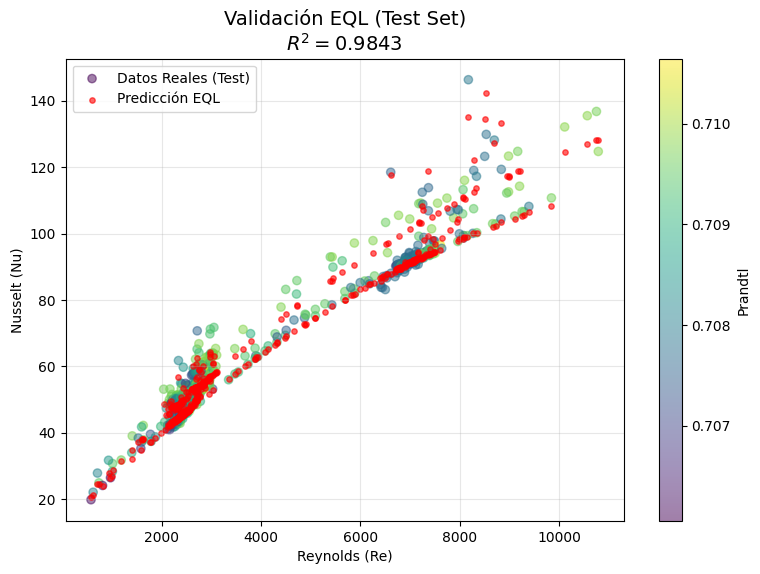

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from EQL.model import EQL

# --- FUNCIÓN DE SEGURIDAD (PODA) ---
def podar_modelo(eql_model, umbral):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
file_path = "/content/df_n_74.txt"

print("--- CARGANDO DATOS ---")
try:
    data = pd.read_csv(file_path)
    print(f"Archivo cargado: {file_path}")
except FileNotFoundError:
    print("Buscando ruta local...")
    try:
        data = pd.read_csv("df_n_25.txt")
        print("Archivo local cargado.")
    except:
        raise

# Limpieza física
data = data.dropna()
mask_valid = (data['Rem'] > 0) & (data['prandtl'] > 0) & (data['nusselt'] > 0)
data = data[mask_valid].copy()

# Definición variables
inputs = ['Rem', 'prandtl', 'K']
output = 'nusselt'

X_raw = data[inputs].values
y_raw = data[output].values.reshape(-1, 1)

print(f"Datos válidos: {len(data)}")

# --- 2. NORMALIZACIÓN ---
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0) + 1e-6
y_mean = y_raw.mean()
y_std  = y_raw.std() + 1e-6

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

ys, ym = y_std, y_mean

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# --- 3. CONFIGURACIÓN Y ENTRENAMIENTO ---
tf.keras.backend.clear_session()

# Configuración solicitada: v=[1, 2, 1]
num_inputs = X_train.shape[1]
eql_nu = EQL(num_layers=3, dim=num_inputs, v=[1, 2, 1])
eql_nu.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("\n--- INICIANDO ENTRENAMIENTO ---")
history = eql_nu.fit(
    X_train, y_train,
    lmbda=1e-3,
    t0=2500,
    t1=7000,
    t2=500,
    verbose=1, # Verbose activado
    atol=1e-3
)
print("Entrenamiento finalizado.")

# --- 4. EXTRACCIÓN DE FÓRMULA ---
print("\n--- PROCESANDO FÓRMULA ---")
podar_modelo(eql_nu, umbral=0.01)

# Chequeo anti-cuelgue
pesos_activos = sum(np.sum(np.abs(l.w.numpy()) > 0) for l in eql_nu.model.layers if hasattr(l, 'w'))
print(f"Pesos activos: {pesos_activos}")

if pesos_activos > 20:
    print(">> Poda agresiva (0.05) aplicada...")
    podar_modelo(eql_nu, umbral=0.05)

try:
    if pesos_activos <= 25:
        raw_formula = str(eql_nu.formula())
        translated = (raw_formula.replace("x0", "Re")
                                 .replace("x1", "Pr")
                                 .replace("x2", "K")
                                 .replace("x3", "1"))
        print("\n=== ECUACIÓN DESCUBIERTA ===")
        print(translated)
    else:
        print("Fórmula muy larga, se omite impresión.")
except Exception as e:
    print(f"No se pudo imprimir fórmula: {e}")

# --- 5. CÁLCULO DE MÉTRICAS (TRAIN y TEST) ---
print("\n--- RESULTADOS Y MÉTRICAS ---")

def get_metrics(X_n, y_n, model, label):
    # Desnormalizar Real
    y_real = y_n.flatten() * ys + ym
    # Predecir y Desnormalizar
    y_pred = model.predict(X_n, verbose=0).flatten() * ys + ym

    # Cálculos
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    rango = y_real.max() - y_real.min()
    nrmse = rmse / rango

    print(f"SET {label}:")
    print(f"  R^2 Score: {r2:.5f}")
    print(f"  NRMSE:     {nrmse:.5f} ({nrmse*100:.2f}%)")
    return r2, y_real, y_pred

# Métricas Train
r2_train, _, _ = get_metrics(X_train, y_train, eql_nu, "ENTRENAMIENTO")
print("-" * 30)
# Métricas Test
r2_test, y_test_real, y_pred_test = get_metrics(X_test, y_test, eql_nu, "TEST")
print("-" * 30)

# --- 6. GRÁFICO (SOLO TEST) ---
# Preparar eje X (Reynolds) desnormalizado
X_test_real = X_test * X_std + X_mean
Re_test_real = X_test_real[:, 0]
Pr_test_real = X_test_real[:, 1] # Para color

plt.figure(figsize=(9, 6))

# Datos Reales
sc = plt.scatter(Re_test_real, y_test_real,
                 c=Pr_test_real, cmap='viridis',
                 alpha=0.5, label='Datos Reales (Test)')

# Predicción
plt.scatter(Re_test_real, y_pred_test,
            color='red', s=15, alpha=0.6, label='Predicción EQL')

plt.colorbar(sc, label='Prandtl')
plt.xlabel('Reynolds (Re)')
plt.ylabel('Nusselt (Nu)')
plt.title(f'Validación EQL (Test Set)\n$R^2 = {r2_test:.4f}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se han truncado las últimas 5000 líneas del flujo de salida.
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5010/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5011/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5012/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5013/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5014/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5015/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0190
Epoch 5016/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0189
Epoch 5017/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5018/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0191
Epoch 5019/7000
93/93 [==============================] - 0s 4ms/step - loss: 0.0192
Epoch 5020/7000
93/93 [========

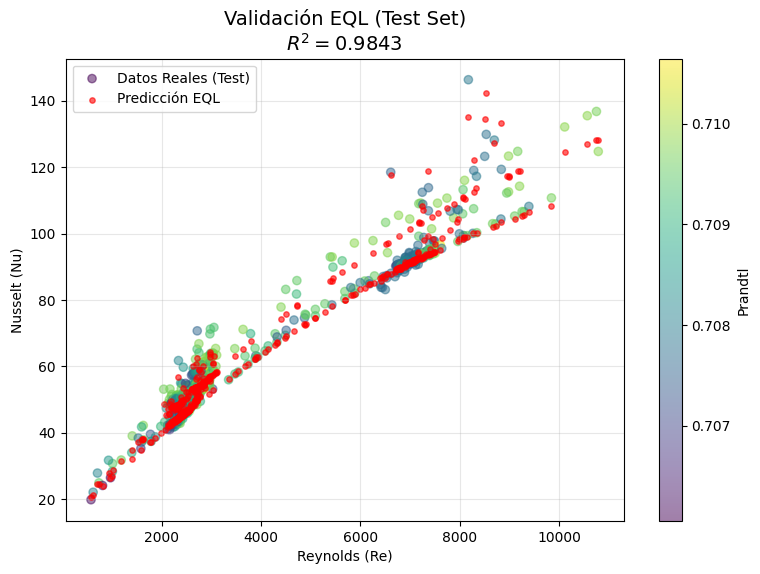

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from EQL.model import EQL

# --- FUNCIÓN DE SEGURIDAD (PODA) ---
def podar_modelo(eql_model, umbral):
    count = 0
    for layer in eql_model.model.layers:
        if hasattr(layer, 'w'):
            w = layer.w.numpy()
            mask = np.abs(w) < umbral
            count += np.sum(mask)
            w[mask] = 0.0
            layer.w.assign(w)
    return count

# --- 1. CARGA Y LIMPIEZA DE DATOS ---
file_path = "/content/df_n_102.txt"

print("--- CARGANDO DATOS ---")
try:
    data = pd.read_csv(file_path)
    print(f"Archivo cargado: {file_path}")
except FileNotFoundError:
    print("Buscando ruta local...")
    try:
        data = pd.read_csv("df_n_25.txt")
        print("Archivo local cargado.")
    except:
        raise

# Limpieza física
data = data.dropna()
mask_valid = (data['Rem'] > 0) & (data['prandtl'] > 0) & (data['nusselt'] > 0)
data = data[mask_valid].copy()

# Definición variables
inputs = ['Rem', 'prandtl', 'K']
output = 'nusselt'

X_raw = data[inputs].values
y_raw = data[output].values.reshape(-1, 1)

print(f"Datos válidos: {len(data)}")

# --- 2. NORMALIZACIÓN ---
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0) + 1e-6
y_mean = y_raw.mean()
y_std  = y_raw.std() + 1e-6

X_norm = (X_raw - X_mean) / X_std
y_norm = (y_raw - y_mean) / y_std

ys, ym = y_std, y_mean

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)

# --- 3. CONFIGURACIÓN Y ENTRENAMIENTO ---
tf.keras.backend.clear_session()

# Configuración solicitada: v=[1, 2, 1]
num_inputs = X_train.shape[1]
eql_nu = EQL(num_layers=3, dim=num_inputs, v=[1, 2, 1])
eql_nu.build_and_compile_model(w_init='random_normal', b_init='random_normal')

print("\n--- INICIANDO ENTRENAMIENTO ---")
history = eql_nu.fit(
    X_train, y_train,
    lmbda=1e-3,
    t0=2500,
    t1=7000,
    t2=500,
    verbose=1, # Verbose activado
    atol=1e-3
)
print("Entrenamiento finalizado.")

# --- 4. EXTRACCIÓN DE FÓRMULA ---
print("\n--- PROCESANDO FÓRMULA ---")
podar_modelo(eql_nu, umbral=0.01)

# Chequeo anti-cuelgue
pesos_activos = sum(np.sum(np.abs(l.w.numpy()) > 0) for l in eql_nu.model.layers if hasattr(l, 'w'))
print(f"Pesos activos: {pesos_activos}")

if pesos_activos > 20:
    print(">> Poda agresiva (0.05) aplicada...")
    podar_modelo(eql_nu, umbral=0.05)

try:
    if pesos_activos <= 25:
        raw_formula = str(eql_nu.formula())
        translated = (raw_formula.replace("x0", "Re")
                                 .replace("x1", "Pr")
                                 .replace("x2", "K")
                                 .replace("x3", "1"))
        print("\n=== ECUACIÓN DESCUBIERTA ===")
        print(translated)
    else:
        print("Fórmula muy larga, se omite impresión.")
except Exception as e:
    print(f"No se pudo imprimir fórmula: {e}")

# --- 5. CÁLCULO DE MÉTRICAS (TRAIN y TEST) ---
print("\n--- RESULTADOS Y MÉTRICAS ---")

def get_metrics(X_n, y_n, model, label):
    # Desnormalizar Real
    y_real = y_n.flatten() * ys + ym
    # Predecir y Desnormalizar
    y_pred = model.predict(X_n, verbose=0).flatten() * ys + ym

    # Cálculos
    r2 = r2_score(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    rango = y_real.max() - y_real.min()
    nrmse = rmse / rango

    print(f"SET {label}:")
    print(f"  R^2 Score: {r2:.5f}")
    print(f"  NRMSE:     {nrmse:.5f} ({nrmse*100:.2f}%)")
    return r2, y_real, y_pred

# Métricas Train
r2_train, _, _ = get_metrics(X_train, y_train, eql_nu, "ENTRENAMIENTO")
print("-" * 30)
# Métricas Test
r2_test, y_test_real, y_pred_test = get_metrics(X_test, y_test, eql_nu, "TEST")
print("-" * 30)

# --- 6. GRÁFICO (SOLO TEST) ---
# Preparar eje X (Reynolds) desnormalizado
X_test_real = X_test * X_std + X_mean
Re_test_real = X_test_real[:, 0]
Pr_test_real = X_test_real[:, 1] # Para color

plt.figure(figsize=(9, 6))

# Datos Reales
sc = plt.scatter(Re_test_real, y_test_real,
                 c=Pr_test_real, cmap='viridis',
                 alpha=0.5, label='Datos Reales (Test)')

# Predicción
plt.scatter(Re_test_real, y_pred_test,
            color='red', s=15, alpha=0.6, label='Predicción EQL')

plt.colorbar(sc, label='Prandtl')
plt.xlabel('Reynolds (Re)')
plt.ylabel('Nusselt (Nu)')
plt.title(f'Validación EQL (Test Set)\n$R^2 = {r2_test:.4f}$', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()